100%|██████████| 5050/5050 [00:32<00:00, 153.59it/s]


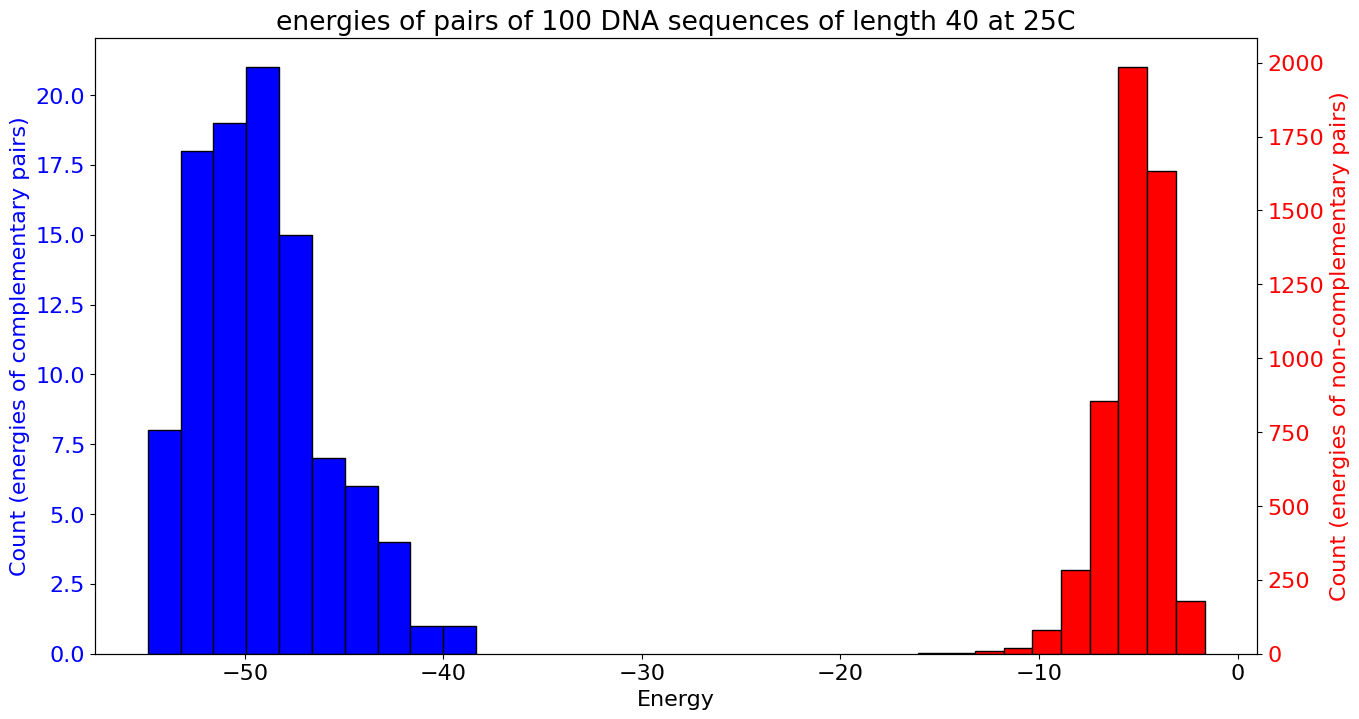

In [13]:
import itertools
import nuad.vienna_nupack as nv
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

length = 40
temperature = 25
num_seqs = 100
seqs = [nv.random_dna_seq(length) for _ in range(num_seqs)]
    
energies_comp = []
for s in tqdm(seqs):
    energy = nv.binding(s, nv.rc(s), temperature=temperature)
    energies_comp.append(energy)

energies = []
for s1, s2 in tqdm(list(itertools.combinations_with_replacement(seqs, 2))):
    energy = nv.binding(s1, s2, temperature=temperature)
    energies.append(energy)

plt.rcParams.update({'font.size': 16})
fig, ax1 = plt.subplots(figsize=(15, 8))
# plt.ylabel('count')
plt.xlabel('binding energy (kcal/mol)')
# _=plt.hist(energies, bins=20, edgecolor='black')


# Plot histogram of energies on ax1
counts1, bins, patches1 = ax1.hist(energies_comp, bins=10, color='blue', edgecolor='black')
ax1.set_xlabel("Energy")
ax1.set_ylabel("Count (energies of complementary pairs)", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create twin axis for energies_comp
ax2 = ax1.twinx()

# Plot histogram of energies_comp on ax2 with SAME bins
ax2.hist(energies, bins=10, color='red', edgecolor='black')
ax2.set_ylabel("Count (energies of non-complementary pairs)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title(f'energies of pairs of {num_seqs} DNA sequences of length {length} at {temperature}C')

plt.show()

In [4]:
import nupack

seq = 'AGCTAGCTAGTCGTAGCTAGTCGATCGATCGATGCTAGCTAGCTAG'

for name, material, ensemble in [
    ('NUPACK 3', 'dna04-nupack3', nupack.Ensemble.all_nupack3),
    ('NUPACK 4', 'dna', nupack.Ensemble.stacking),
]:
    model = nupack.Model(material=material, ensemble=ensemble)
    _, complex_free_energy = nupack.pfunc(seq, model=model)
    print(f'{name} complex_free_energy: {complex_free_energy}')

NUPACK 3 complex_free_energy: -12.08341230338398
NUPACK 4 complex_free_energy: -12.391311055132118


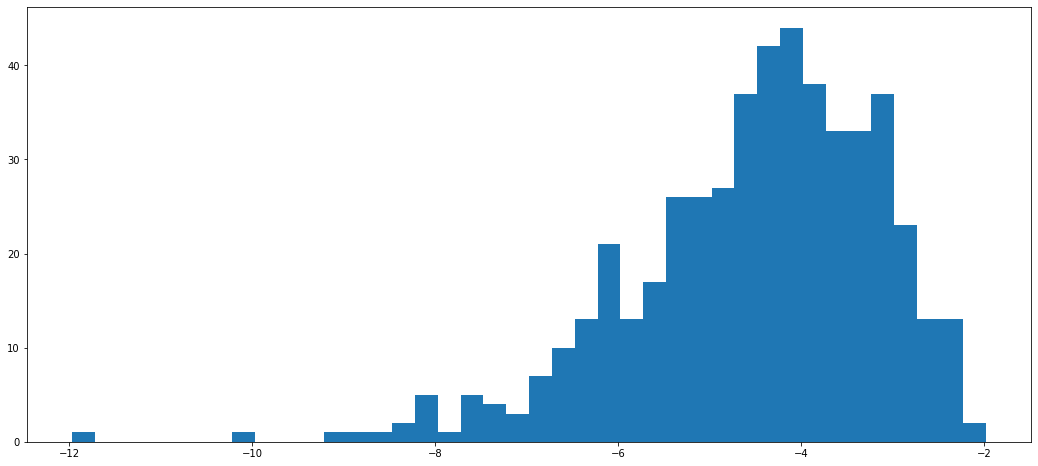

In [19]:
import nuad.vienna_nupack as nv

seqs = [nv.random_dna_seq(42) for _ in range(500)]
cfes = [nv.pfunc(seq) for seq in seqs]
plt.figure(figsize=(18,8))
_ = plt.hist(cfes, bins=40)

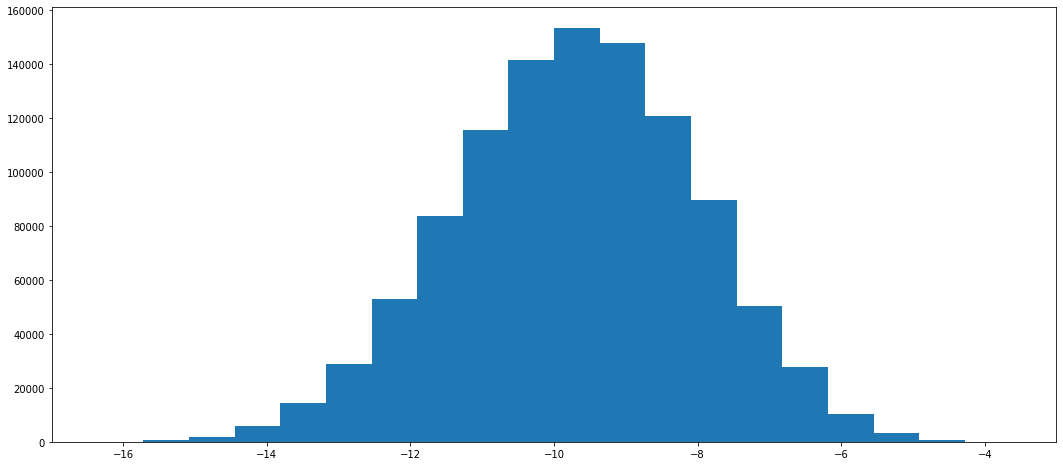

In [10]:
import nuad.np as nn
import matplotlib.pyplot as plt

s10 = nn.DNASeqList(length=10)
# s11 = nn.DNASeqList(length=11)
energies10 = s10.energies(52)
# energies11 = s.energies(52)
# energies = energies10+energies11
# print(f'{min(energies)=}')
# print(f'{max(energies)=}')
plt.figure(figsize=(18,8))
_ = plt.hist(energies10, bins=20)

In [2]:
(191/255, 87/255, 0/255)

(0.7490196078431373, 0.3411764705882353, 0.0)

In [1]:
t = (2,3)
s = tuple(t)
s is t

True